In [118]:
import numpy as np
import ase
import matplotlib.pyplot as plt
import os

from ase.build import graphene

In [119]:
rot = np.deg2rad(0)
angle = np.deg2rad(0)
amplitude = 0.3

strain = amplitude * np.array([
    [np.cos(angle), 0,0],
    [0, np.sin(angle), 0],
    [0, 0, 0]
])

deformation = np.eye(3) + strain
rotation = np.array([
    [np.cos(rot), -np.sin(rot), 0],
    [np.sin(rot), np.cos(rot), 0],
    [0, 0, 1]
])

In [120]:
atoms = graphene()
atoms.cell[2,2]=100

atoms.set_cell(np.dot(atoms.cell, rotation), scale_atoms=True)
atoms.set_cell(np.dot(atoms.cell, deformation), scale_atoms=True)

reciprocal_cell = atoms.cell.reciprocal()

In [121]:
atoms.cell

Cell([[3.198, 0.0, 0.0], [-1.599, 2.130422493309719, 0.0], [0.0, 0.0, 100.0]])

In [122]:
grid_fractional = ase.dft.monkhorst_pack((10,10,1))
grid_cartesian = np.dot(grid_fractional, reciprocal_cell)

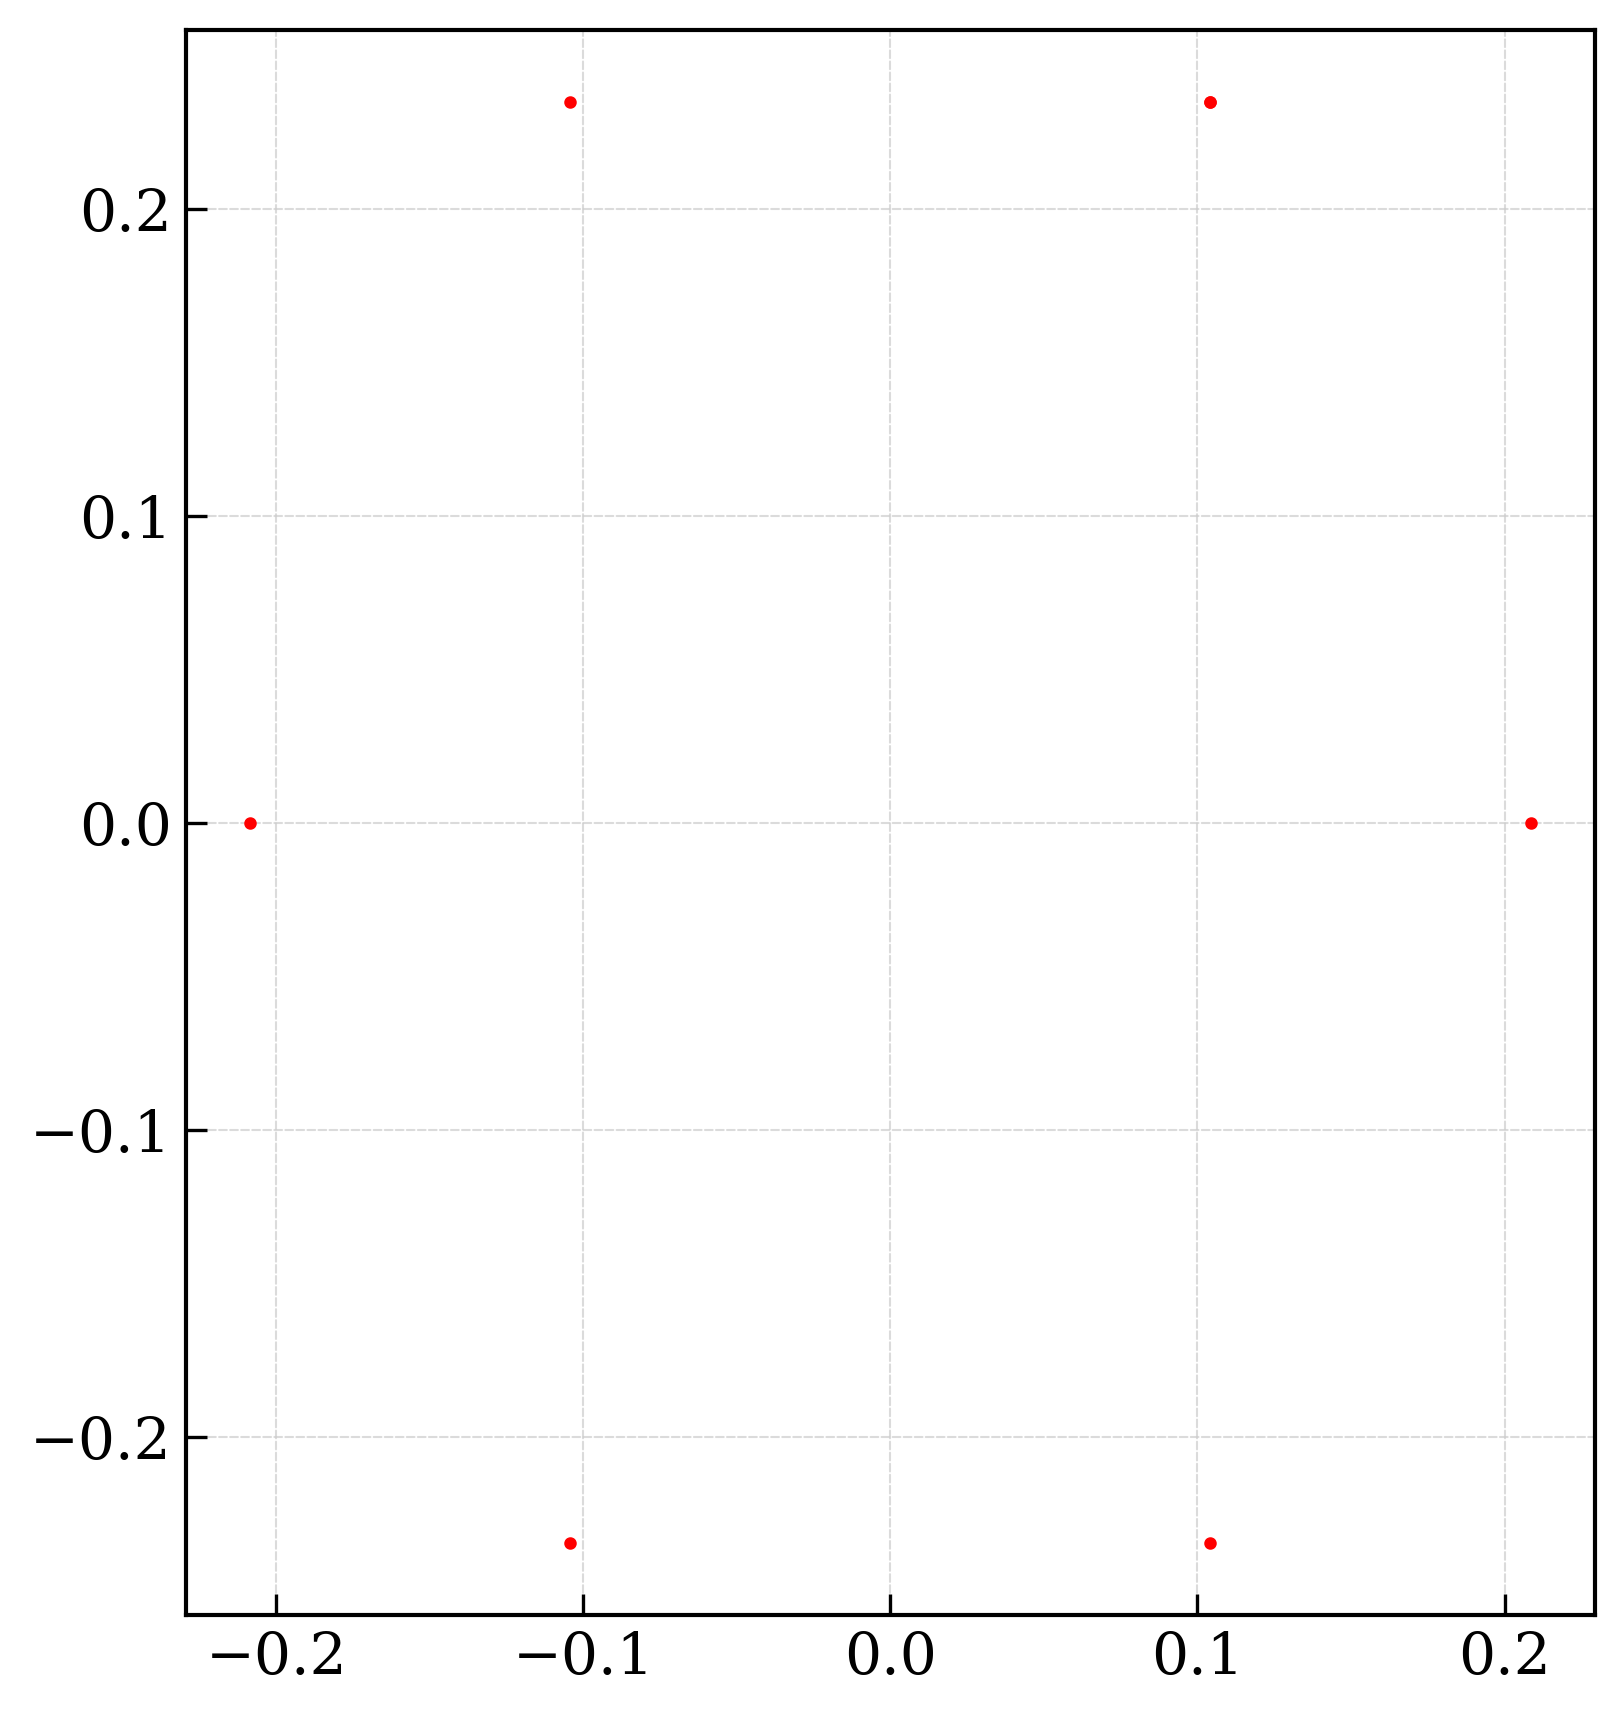

In [123]:
vertices_fractional = np.array([
    [1/3, 1/3, 0],
    [2/3, -1/3, 0],
    [1/3, -2/3, 0],
    [-1/3, -1/3, 0],
    [-2/3, 1/3, 0],
    [-1/3, 2/3, 0],
    [1/3, 1/3, 0]
])

vertices_cartesian = np.dot(vertices_fractional, reciprocal_cell)

fig, ax = plt.subplots(figsize=(6,6))
plt.scatter(vertices_cartesian[:,0], vertices_cartesian[:,1], color='red', label='Vertices')
ax.set_aspect('equal')

In [128]:
import numpy as np
from scipy.spatial import cKDTree

def map_to_first_bz(kpoints, reciprocal_cell):
    """
    Maps an array of Cartesian k-points to the true first Brillouin Zone.
    Guaranteed to work even for highly deformed, sheared, or skewed cells.
    
    Parameters:
    -----------
    kpoints : array_like of shape (N, 3) or (3,)
    reciprocal_cell : array_like of shape (3, 3)
    """
    kpoints = np.asarray(kpoints, dtype=float)
    B = np.asarray(reciprocal_cell, dtype=float)
    
    is_single_point = (kpoints.ndim == 1)
    if is_single_point:
        kpoints = kpoints[np.newaxis, :]
        
    # 1. Map to central parallel-piped unit cell first
    frac_k = np.linalg.solve(B.T, kpoints.T).T
    frac_k_wrapped = frac_k - np.round(frac_k)
    k_wrapped = frac_k_wrapped @ B

    # 2. Dynamically calculate the required neighbor search size.
    # For highly deformed cells, a 3x3x3 grid is not enough. We determine 
    # how many grid shifts are needed based on the cell geometry.
    # This copies the robust logic used in calculating crystal neighbor lists.
    inv_B = np.linalg.inv(B)
    cross_norms = np.cross(B[[1, 2, 0]], B[[2, 0, 1]], axis=1)
    cross_norms = np.linalg.norm(cross_norms, axis=1)
    volumes = np.abs(np.linalg.det(B))
    
    # Perpendicular distances between parallel lattice planes
    d_perp = volumes / cross_norms 
    
    # Find the maximum radius of the central wrapped k-point cluster
    max_k_radius = np.max(np.linalg.norm(k_wrapped, axis=1)) if len(k_wrapped) > 0 else 0
    # To be safe, we want to look at all G vectors within a reasonable bounding sphere
    search_radius = max_k_radius + np.max(np.linalg.norm(B, axis=1))
    
    # Calculate limits for n1, n2, n3
    n_limits = np.ceil(search_radius / d_perp).astype(int)
    
    # 3. Build the definitive grid of G-vectors
    n1 = np.arange(-n_limits[0], n_limits[0] + 1)
    n2 = np.arange(-n_limits[1], n_limits[1] + 1)
    n3 = np.arange(-n_limits[2], n_limits[2] + 1)
    
    grid = np.meshgrid(n1, n2, n3, indexing='ij')
    G_indices = np.stack([g.ravel() for g in grid], axis=-1)
    G_vectors = G_indices @ B

    # 4. Use a KDTree for incredibly fast, vectorized nearest-neighbor lookup
    tree = cKDTree(G_vectors)
    _, closest_G_idx = tree.query(k_wrapped, k=1)
    
    best_G = G_vectors[closest_G_idx]
    
    # 5. Shift back to the first BZ
    mapped_kpoints = k_wrapped - best_G
    
    return mapped_kpoints[0] if is_single_point else mapped_kpoints

first_bz_grid = map_to_first_bz(grid_cartesian, reciprocal_cell=reciprocal_cell)

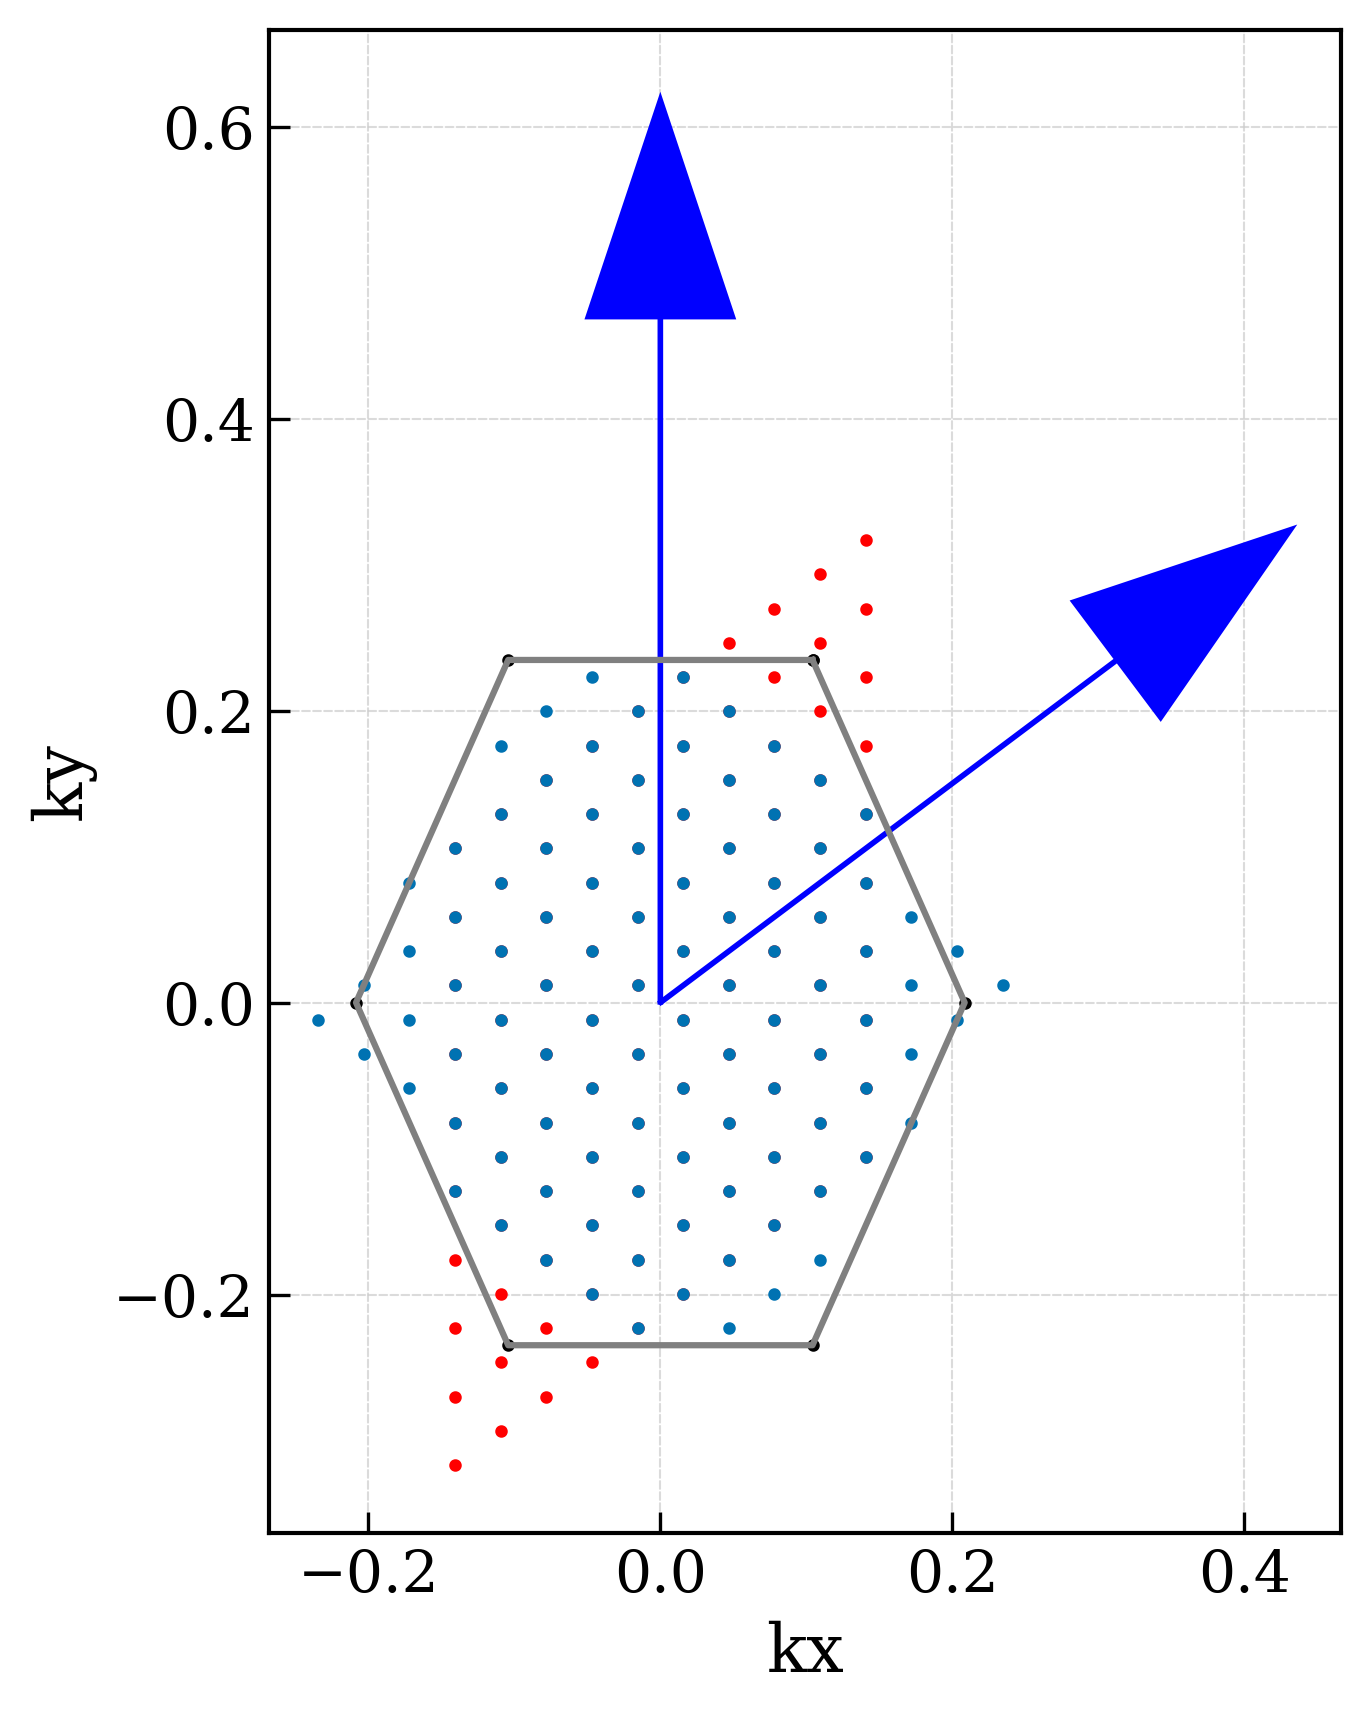

In [129]:
fig, ax = plt.subplots(figsize=(6,6))

plt.scatter(vertices_cartesian[:,0], vertices_cartesian[:,1], color='k')
plt.plot(vertices_cartesian[:,0], vertices_cartesian[:,1], color='grey')
plt.scatter(grid_cartesian[:,0], grid_cartesian[:,1], color='red')
plt.scatter(first_bz_grid[:,0], first_bz_grid[:,1])

plt.arrow(0,0, reciprocal_cell[0,0], reciprocal_cell[0,1], color='blue', head_width=0.1)
plt.arrow(0,0, reciprocal_cell[1,0], reciprocal_cell[1,1], color='blue', head_width=0.1)

plt.xlabel('kx')
plt.ylabel('ky')

ax.set_aspect('equal')

